In [1]:
# ============================================
# Cell 1: Import Libraries
# ============================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.cloud import bigquery
import pydata_google_auth

In [2]:
# ============================================
# Cell 2: Load Data from BigQuery
# ============================================
print("Authenticating with Google Cloud...")
credentials = pydata_google_auth.get_user_credentials(
    ['https://www.googleapis.com/auth/cloud-platform']
)

PROJECT_ID = "pearl-aqi-predictor"
bq_client = bigquery.Client(project=PROJECT_ID, credentials=credentials)

print("Downloading Multan AQI data from BigQuery...")
query = f"""
    SELECT * 
    FROM `{PROJECT_ID}.aqi_feature_store.multan_historical`
    ORDER BY timestamp ASC
"""

df = bq_client.query(query).to_dataframe()

print("\nData successfully loaded for Machine Learning!")
df.head()

Authenticating with Google Cloud...


E:\anaconda\Lib\site-packages\google\cloud\bigquery\table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(



Data successfully loaded for Machine Learning!


,city,timestamp,aqi,pm2_5,pm10,no2,so2,o3,co
0,Multan,2024-01-01 00:00:00,5.0,225.15,237.34,18.51,2.92,32.54,1482.01
1,Multan,2024-01-01 01:00:00,5.0,221.95,233.21,19.88,2.21,25.75,1535.42
2,Multan,2024-01-01 02:00:00,5.0,227.53,242.57,27.42,3.07,15.74,1789.09
3,Multan,2024-01-01 03:00:00,5.0,239.53,260.16,38.39,4.23,7.51,2109.53
4,Multan,2024-01-01 04:00:00,5.0,221.19,248.61,35.99,4.41,26.11,1922.61


In [3]:
# ============================================
# Cell 3: Initial Data Exploration
# ============================================
print("Shape:", df.shape)
print("\nDtypes:\n", df.dtypes)
print("\nMissing values:\n", df.isnull().sum())
print("\nDuplicates:", df.duplicated().sum())
print("\nStatistical summary:")
df.describe()

Shape: (20370, 9)

Dtypes:
 city                 object
timestamp    datetime64[us]
aqi                 float64
pm2_5               float64
pm10                float64
no2                 float64
so2                 float64
o3                  float64
co                  float64
dtype: object

Missing values:
 city         0
timestamp    0
aqi          0
pm2_5        0
pm10         0
no2          0
so2          0
o3           0
co           0
dtype: int64

Duplicates: 0

Statistical summary:


,timestamp,aqi,pm2_5,pm10,no2,so2,o3,co
count,20370,20370.000000,20370.000000,20370.000000,20370.000000,20370.000000,20370.000000,20370.000000
mean,2025-03-10 05:31:42.857142,4.068974,93.140633,152.157383,12.917508,5.604735,77.112444,835.407903
min,2024-01-01 00:00:00,1.000000,0.000000,-9999.000000,-9999.000000,0.130000,0.000000,101.260000
25%,2024-08-04 04:15:00,3.000000,32.730000,72.390000,3.600000,2.290000,42.920000,338.012500
50%,2025-03-07 08:30:00,4.000000,57.095000,116.815000,8.220000,3.870000,70.810000,587.460000
75%,2025-10-13 12:45:00,5.000000,122.350000,202.767500,17.990000,6.560000,108.720000,1134.870000
max,2026-05-24 17:00:00,5.777766,558.370000,680.990000,180.960000,91.550000,308.990000,5981.450000
std,NaN,0.938372,88.906024,133.639187,100.551042,5.887363,44.714958,713.606822


In [4]:
# ============================================
# Cell 4: Set Index and Check Time Range
# ============================================
df["timestamp"] = pd.to_datetime(df["timestamp"])
df = df.sort_values('timestamp').reset_index(drop=True)
df = df.set_index("timestamp")

print("Data Range:", df.index.min(), df.index.max())
print("Total hours:", len(df))

Data Range: 2024-01-01 00:00:00 2026-05-24 17:00:00
Total hours: 20370


In [5]:
# ============================================
# Cell 5: Check for Missing Hourly Gaps
# ============================================
expected_range = pd.date_range(start=df.index.min(), end=df.index.max(), freq="h")
missing_hours = expected_range.difference(df.index)

print(f"Missing hourly gaps: {len(missing_hours)}")
print(missing_hours[:10])

Missing hourly gaps: 624
DatetimeIndex(['2024-01-09 01:00:00', '2024-01-09 02:00:00',
               '2024-01-09 03:00:00', '2024-01-09 04:00:00',
               '2024-01-09 05:00:00', '2024-01-09 06:00:00',
               '2024-01-09 07:00:00', '2024-01-09 08:00:00',
               '2024-01-09 09:00:00', '2024-01-09 10:00:00'],
              dtype='datetime64[ns]', freq=None)


In [6]:
# ============================================
# Cell 6: Interpolate Missing Values
# ============================================
df_clean = df.copy()

pollutants = ['pm2_5', 'pm10', 'no2', 'so2', 'o3', 'co', 'aqi']

for col in pollutants:
    n_missing = df_clean[col].isnull().sum()
    if n_missing > 0:
        print(f"  {col}: {n_missing} missing → interpolating")
        df_clean[col] = df_clean[col].interpolate(method='time', limit=3)

before = len(df_clean)
df_clean = df_clean.dropna(subset=pollutants)
print(f"\nDropped {before - len(df_clean)} rows with large gaps")


Dropped 0 rows with large gaps


In [7]:
# ============================================
# Cell 7: Cap Outliers Using IQR
# ============================================
def cap_outliers_iqr(series, factor=3.0):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - factor * IQR
    upper = Q3 + factor * IQR
    n_capped = ((series < lower) | (series > upper)).sum()
    capped = series.clip(lower=lower, upper=upper)
    return capped, n_capped, lower, upper

print("Outlier capping report:")
print(f"{'Column':<10} {'Capped':>8} {'Lower':>10} {'Upper':>10}")
print("-" * 42)

for col in pollutants:
    df_clean[col], n, lo, hi = cap_outliers_iqr(df_clean[col])
    print(f"{col:<10} {n:>8}  {lo:>10.2f}  {hi:>10.2f}")

Outlier capping report:
Column       Capped      Lower      Upper
------------------------------------------
pm2_5           275     -236.13      391.21
pm10             33     -318.74      593.90
no2             439      -39.57       61.16
so2             718      -10.52       19.37
o3                2     -154.48      306.12
co              146    -2052.56     3525.44
aqi               0       -3.00       11.00


In [8]:
# ============================================
# Cell 8: Check AQI Distribution
# ============================================
print("AQI value distribution:")
print(df_clean['aqi'].value_counts().head(20))
print(f"\nUnique AQI values: {df_clean['aqi'].nunique()}")
print(f"AQI range: {df_clean['aqi'].min()} → {df_clean['aqi'].max()}")

print("\n── Sample rows ─────────────────────────────────────────")
print(df_clean[['pm2_5', 'pm10', 'no2', 'so2', 'o3', 'co', 'aqi']].head(10))

AQI value distribution:
aqi
5.000000    8492
4.000000    5950
3.000000    4821
2.000000    1046
1.000000      59
5.222197       1
5.777766       1
Name: count, dtype: int64

Unique AQI values: 7
AQI range: 1.0 → 5.777766227722168

── Sample rows ─────────────────────────────────────────
                      pm2_5    pm10    no2    so2     o3       co  aqi
timestamp                                                             
2024-01-01 00:00:00  225.15  237.34  18.51   2.92  32.54  1482.01  5.0
2024-01-01 01:00:00  221.95  233.21  19.88   2.21  25.75  1535.42  5.0
2024-01-01 02:00:00  227.53  242.57  27.42   3.07  15.74  1789.09  5.0
2024-01-01 03:00:00  239.53  260.16  38.39   4.23   7.51  2109.53  5.0
2024-01-01 04:00:00  221.19  248.61  35.99   4.41  26.11  1922.61  5.0
2024-01-01 05:00:00  223.20  250.27  36.67   4.83  25.03  2002.72  5.0
2024-01-01 06:00:00  224.55  248.12  40.10   5.66  21.46  2189.64  5.0
2024-01-01 07:00:00  193.70  214.84  33.93  11.68  54.36  1842.50  5.0
20

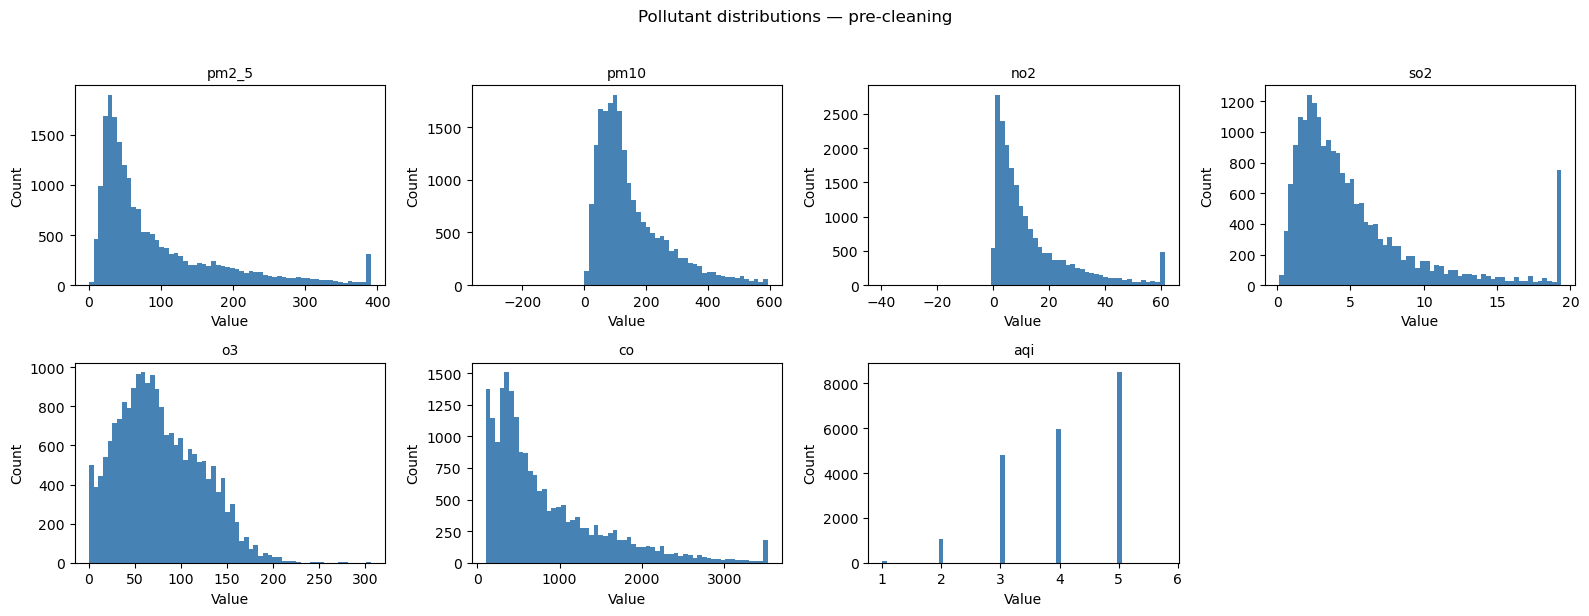

In [9]:
# ============================================
# Cell 9: Visualize Pollutant Distributions
# ============================================
fig, axes = plt.subplots(2, 4, figsize=(16, 6))
axes = axes.flatten()

for i, col in enumerate(['pm2_5', 'pm10', 'no2', 'so2', 'o3', 'co', 'aqi']):
    axes[i].hist(df_clean[col].dropna(), bins=60, color='steelblue', edgecolor='none')
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Count')

axes[-1].set_visible(False)
plt.suptitle("Pollutant distributions — pre-cleaning", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

In [10]:
# ============================================
# Cell 10: Drop Original AQI Column for Recalculation
# ============================================
df_clean = df_clean.drop(columns=['aqi'])

In [11]:
# ============================================
# Cell 11: Clip Negative Values to Zero
# ============================================
physical_cols = ['pm2_5', 'pm10', 'no2', 'so2', 'o3', 'co']
for col in physical_cols:
    n_neg = (df_clean[col] < 0).sum()
    if n_neg > 0:
        print(f"  {col}: clipped {n_neg} negative values to 0")
    df_clean[col] = df_clean[col].clip(lower=0)

  pm10: clipped 1 negative values to 0
  no2: clipped 2 negative values to 0


In [12]:
# ============================================
# Cell 12: Define EPA Breakpoints for AQI Calculation
# ============================================
def compute_sub_aqi(C, breakpoints):
    for (C_low, C_high, AQI_low, AQI_high) in breakpoints:
        if C_low <= C <= C_high:
            return ((AQI_high - AQI_low) / (C_high - C_low)) * (C - C_low) + AQI_low
    return np.nan

BP_PM25 = [
    (0.0,  12.0,   0,  50),
    (12.1, 35.4,  51, 100),
    (35.5, 55.4, 101, 150),
    (55.5, 150.4,151, 200),
    (150.5,250.4,201, 300),
    (250.5,350.4,301, 400),
    (350.5,500.4,401, 500),
]

BP_PM10 = [
    (0,   54,   0,  50),
    (55,  154,  51, 100),
    (155, 254, 101, 150),
    (255, 354, 151, 200),
    (355, 424, 201, 300),
    (425, 504, 301, 400),
    (505, 604, 401, 500),
]

BP_NO2 = [
    (0,   53,   0,  50),
    (54,  100,  51, 100),
    (101, 360, 101, 150),
    (361, 649, 151, 200),
    (650,1249, 201, 300),
    (1250,1649,301, 400),
    (1650,2049,401, 500),
]

BP_SO2 = [
    (0,   35,   0,  50),
    (36,  75,  51, 100),
    (76,  185, 101, 150),
    (186, 304, 151, 200),
    (305, 604, 201, 300),
    (605, 804, 301, 400),
    (805,1004, 401, 500),
]

BP_O3 = [
    (0.000, 0.054,  0,  50),
    (0.055, 0.070, 51, 100),
    (0.071, 0.085,101, 150),
    (0.086, 0.105,151, 200),
    (0.106, 0.200,201, 300),
]

BP_CO = [
    (0.0,  4.4,   0,  50),
    (4.5,  9.4,  51, 100),
    (9.5,  12.4,101, 150),
    (12.5, 15.4,151, 200),
    (15.5, 30.4,201, 300),
    (30.5, 40.4,301, 400),
    (40.5, 50.4,401, 500),
]

In [13]:
# ============================================
# Cell 13: Recompute AQI Using EPA Formula
# ============================================
df_clean['co_ppm'] = df_clean['co'] / 1145.0
df_clean['o3_ppm'] = df_clean['o3'] / 1960.0

df_clean['aqi_pm25'] = df_clean['pm2_5'].apply(lambda x: compute_sub_aqi(x, BP_PM25))
df_clean['aqi_pm10'] = df_clean['pm10'].apply(lambda x: compute_sub_aqi(x, BP_PM10))
df_clean['aqi_no2']  = df_clean['no2'].apply(lambda x: compute_sub_aqi(x, BP_NO2))
df_clean['aqi_so2']  = df_clean['so2'].apply(lambda x: compute_sub_aqi(x, BP_SO2))
df_clean['aqi_o3']   = df_clean['o3_ppm'].apply(lambda x: compute_sub_aqi(x, BP_O3))
df_clean['aqi_co']   = df_clean['co_ppm'].apply(lambda x: compute_sub_aqi(x, BP_CO))

sub_aqi_cols = ['aqi_pm25', 'aqi_pm10', 'aqi_no2', 'aqi_so2', 'aqi_o3', 'aqi_co']
df_clean['aqi'] = df_clean[sub_aqi_cols].max(axis=1)

df_clean = df_clean.drop(columns=['co_ppm', 'o3_ppm'] + sub_aqi_cols)

print("New AQI distribution:")
print(df_clean['aqi'].describe().round(1))
print(f"\nNaN AQI values: {df_clean['aqi'].isna().sum()}")

New AQI distribution:
count    20370.0
mean       160.9
std         83.6
min         13.5
25%         98.1
50%        152.4
75%        186.8
max        489.9
Name: aqi, dtype: float64

NaN AQI values: 0


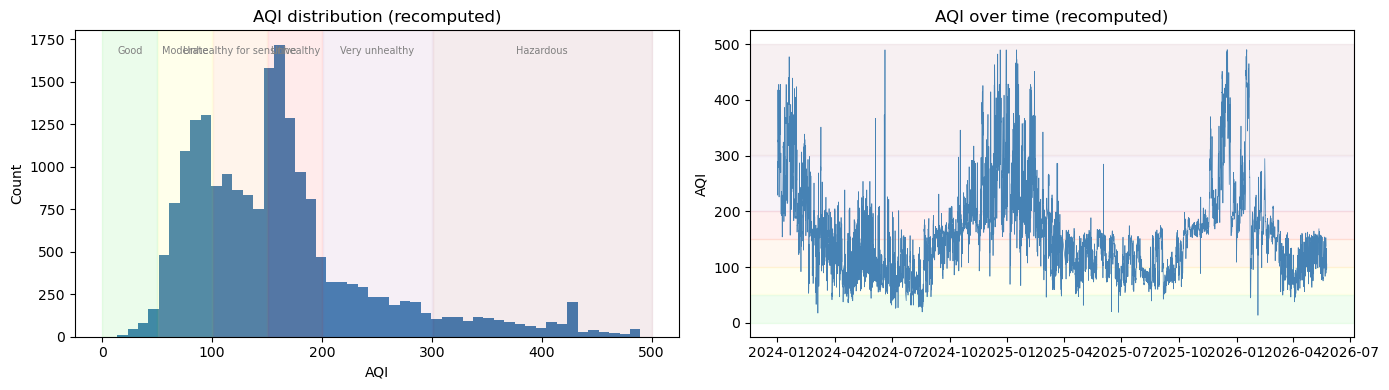

In [14]:
# ============================================
# Cell 14: Visualize Recalculated AQI
# ============================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

ax1.hist(df_clean['aqi'].dropna(), bins=50, color='steelblue', edgecolor='none')
ax1.set_xlabel('AQI')
ax1.set_ylabel('Count')
ax1.set_title('AQI distribution (recomputed)')

bands = [(0,50,'Good','#00e400'),
         (51,100,'Moderate','#ffff00'),
         (101,150,'Unhealthy for sensitive','#ff7e00'),
         (151,200,'Unhealthy','#ff0000'),
         (201,300,'Very unhealthy','#8f3f97'),
         (301,500,'Hazardous','#7e0023')]

for lo, hi, label, color in bands:
    ax1.axvspan(lo, hi, alpha=0.08, color=color)
    ax1.text((lo+hi)/2, ax1.get_ylim()[1]*0.95, label,
             ha='center', va='top', fontsize=7, color='gray')

ax2.plot(df_clean.index, df_clean['aqi'], linewidth=0.5, color='steelblue')
ax2.set_title('AQI over time (recomputed)')
ax2.set_ylabel('AQI')

for lo, hi, _, color in bands:
    ax2.axhspan(lo, hi, alpha=0.06, color=color)

plt.tight_layout()
plt.show()

In [15]:
# ============================================
# Cell 15: Prepare Data for Feature Engineering
# ============================================
df_feat = df_clean.copy()

if 'city' in df_feat.columns:
    df_feat = df_feat.drop(columns=['city'])
    print("Dropped 'city' column")

print("\nColumn dtypes:")
print(df_feat.dtypes)
print("\nNon-numeric columns:", df_feat.select_dtypes(exclude='number').columns.tolist())

Dropped 'city' column

Column dtypes:
pm2_5    float64
pm10     float64
no2      float64
so2      float64
o3       float64
co       float64
aqi      float64
dtype: object

Non-numeric columns: []


In [16]:
# ============================================
# Cell 16: Create Lag Features
# ============================================
lag_hours = [1, 2, 3, 6, 12, 24, 48, 72]

for lag in lag_hours:
    df_feat[f'aqi_lag_{lag}h'] = df_feat['aqi'].shift(lag)

for lag in [1, 3, 6, 24]:
    df_feat[f'pm25_lag_{lag}h'] = df_feat['pm2_5'].shift(lag)
    df_feat[f'co_lag_{lag}h']   = df_feat['co'].shift(lag)

print(f"Lag features added: {len(lag_hours) + 4*2}")

Lag features added: 16


In [17]:
# ============================================
# Cell 17: Create Rolling Window Features
# ============================================
for window in [3, 6, 12, 24]:
    df_feat[f'aqi_roll_mean_{window}h'] = df_feat['aqi'].shift(1).rolling(window).mean()
    df_feat[f'aqi_roll_std_{window}h'] = df_feat['aqi'].shift(1).rolling(window).std()

for col in ['pm2_5', 'co', 'no2']:
    for window in [6, 24]:
        df_feat[f'{col}_roll_mean_{window}h'] = df_feat[col].shift(1).rolling(window).mean()

print(f"Rolling features added: {4*2 + 3*2}")

Rolling features added: 14


In [18]:
# ============================================
# Cell 18: Create Rate of Change Features
# ============================================
df_feat['aqi_diff_1h']  = df_feat['aqi'].shift(1).diff(1)
df_feat['aqi_diff_3h']  = df_feat['aqi'].shift(1).diff(3)
df_feat['aqi_diff_24h'] = df_feat['aqi'].shift(1).diff(24)
df_feat['aqi_trend']    = np.sign(df_feat['aqi_diff_1h'])

print("Change features added: 4")

Change features added: 4


In [19]:
# ============================================
# Cell 19: Create Time-Based Features
# ============================================
df_feat['hour']        = df_feat.index.hour
df_feat['day_of_week'] = df_feat.index.dayofweek
df_feat['month']       = df_feat.index.month
df_feat['day_of_year'] = df_feat.index.dayofyear

df_feat['hour_sin']    = np.sin(2 * np.pi * df_feat['hour'] / 24)
df_feat['hour_cos']    = np.cos(2 * np.pi * df_feat['hour'] / 24)
df_feat['month_sin']   = np.sin(2 * np.pi * df_feat['month'] / 12)
df_feat['month_cos']   = np.cos(2 * np.pi * df_feat['month'] / 12)
df_feat['dow_sin']     = np.sin(2 * np.pi * df_feat['day_of_week'] / 7)
df_feat['dow_cos']     = np.cos(2 * np.pi * df_feat['day_of_week'] / 7)

df_feat['is_morning_peak'] = df_feat['hour'].between(6, 9).astype(int)
df_feat['is_evening_peak'] = df_feat['hour'].between(19, 22).astype(int)

def get_season(month):
    if month in [12, 1, 2]:   return 0
    if month in [3, 4, 5]:    return 1
    if month in [6, 7, 8, 9]: return 2
    return 3

df_feat['season'] = df_feat['month'].apply(get_season)

print("Time features added: 15")

Time features added: 15


In [20]:
# ============================================
# Cell 20: Drop NaN Rows and Finalize Dataset
# ============================================
before = len(df_feat)
df_feat = df_feat.dropna()

dropped = before - len(df_feat)
print(f"Rows dropped (NaN from lags/rolling): {dropped:,}")
print(f"Final dataset: {len(df_feat):,} rows × {df_feat.shape[1]} columns")
print(f"Date range: {df_feat.index.min()} → {df_feat.index.max()}")

Rows dropped (NaN from lags/rolling): 72
Final dataset: 20,298 rows × 54 columns
Date range: 2024-01-04 00:00:00 → 2026-05-24 17:00:00


In [21]:
# ============================================
# Cell 21: Feature Correlation Analysis
# ============================================
feature_cols = [c for c in df_feat.columns if c != 'aqi']

corr = df_feat[feature_cols].corrwith(df_feat['aqi']).abs().sort_values(ascending=False)

print(f"Total features: {len(feature_cols)}")
print("\nTop 20 features by correlation with AQI:")
print(corr.head(20).round(3).to_string())

Total features: 53

Top 20 features by correlation with AQI:
aqi_lag_1h             0.983
pm2_5                  0.971
aqi_roll_mean_3h       0.967
pm25_lag_1h            0.960
aqi_lag_2h             0.960
aqi_roll_mean_6h       0.943
aqi_lag_3h             0.934
pm2_5_roll_mean_6h     0.927
pm25_lag_3h            0.922
pm10                   0.920
aqi_roll_mean_12h      0.915
aqi_roll_mean_24h      0.896
pm2_5_roll_mean_24h    0.883
aqi_lag_6h             0.869
pm25_lag_6h            0.865
aqi_lag_12h            0.813
aqi_lag_24h            0.811
pm25_lag_24h           0.805
co                     0.775
co_lag_1h              0.767


In [22]:
# ============================================
# Cell 22: Save Feature Matrix to BigQuery and Local CSV
# ============================================
df_feat.to_gbq(
    destination_table='aqi_feature_store.multan_features',
    project_id=PROJECT_ID,
    credentials=credentials,
    if_exists='replace'
)
print("Feature matrix saved to BigQuery!")

df_feat.to_csv('multan_features.csv')
print(f"Local CSV saved: multan_features.csv")
print(f"\nReady for model training: {df_feat.shape}")

C:\Users\SMART TECH\AppData\Local\Temp\ipykernel_17140\378804649.py:4: FutureWarning: to_gbq is deprecated and will be removed in a future version. Please use pandas_gbq.to_gbq instead: https://pandas-gbq.readthedocs.io/en/latest/api.html#pandas_gbq.to_gbq
  df_feat.to_gbq(
100%|█████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 15947.92it/s]


Feature matrix saved to BigQuery!
Local CSV saved: multan_features.csv

Ready for model training: (20298, 54)


In [23]:
# ============================================
# Cell 23: Import ML Libraries
# ============================================
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor
import joblib, json, warnings
warnings.filterwarnings('ignore')

In [24]:
# ============================================
# Cell 24: Split Data (Time-Based)
# ============================================
TARGET       = 'aqi'
FEATURE_COLS = [c for c in df_feat.columns if c != TARGET]

X = df_feat[FEATURE_COLS]
y = df_feat[TARGET]

split_idx  = int(len(df_feat) * 0.80)
split_date = df_feat.index[split_idx]

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"Train : {len(X_train):,} rows  ({X_train.index.min().date()} → {X_train.index.max().date()})")
print(f"Test  : {len(X_test):,}  rows  ({X_test.index.min().date()} → {X_test.index.max().date()})")
print(f"Split date: {split_date.date()}")

Train : 16,238 rows  (2024-01-04 → 2025-11-25)
Test  : 4,060  rows  (2025-11-25 → 2026-05-24)
Split date: 2025-11-25


In [25]:
# ============================================
# Cell 25: Scale Features (for Linear Models)
# ============================================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Scaling done — mean ~0, std ~1 for all features")
print(f"Scaler fitted on {X_train_scaled.shape[0]:,} training rows")

Scaling done — mean ~0, std ~1 for all features
Scaler fitted on 16,238 training rows


In [26]:
# ============================================
# Cell 26: Define Evaluation Function
# ============================================
def aqi_category(val):
    if val <= 50:   return 'Good'
    if val <= 100:  return 'Moderate'
    if val <= 150:  return 'Unhealthy (sensitive)'
    if val <= 200:  return 'Unhealthy'
    if val <= 300:  return 'Very unhealthy'
    return 'Hazardous'

def evaluate(name, y_true, y_pred):
    y_pred  = np.clip(y_pred, 0, 500)
    mae     = mean_absolute_error(y_true, y_pred)
    rmse    = np.sqrt(mean_squared_error(y_true, y_pred))
    r2      = r2_score(y_true, y_pred)
    mape    = np.mean(np.abs((y_true - y_pred) / y_true.clip(lower=1))) * 100
    cats_a  = pd.Series(y_true.values).apply(aqi_category)
    cats_p  = pd.Series(y_pred).apply(aqi_category)
    cat_acc = (cats_a == cats_p).mean() * 100
    
    results[name] = dict(MAE=mae, RMSE=rmse, R2=r2, MAPE=mape, CatAcc=cat_acc)
    
    print(f"\n{'─'*45}")
    print(f"  {name}")
    print(f"{'─'*45}")
    print(f"  MAE               : {mae:.2f}")
    print(f"  RMSE              : {rmse:.2f}")
    print(f"  R²                : {r2:.4f}")
    print(f"  MAPE              : {mape:.2f}%")
    print(f"  Category accuracy : {cat_acc:.1f}%")
    return y_pred

results    = {}
all_preds  = {}

In [27]:
# ============================================
# Cell 27: Train Linear Regression
# ============================================
print("Training Linear Regression...")
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
preds_lr = evaluate("Linear Regression", y_test, lr.predict(X_test_scaled))
all_preds["Linear Regression"] = preds_lr

Training Linear Regression...

─────────────────────────────────────────────
  Linear Regression
─────────────────────────────────────────────
  MAE               : 3.86
  RMSE              : 6.66
  R²                : 0.9954
  MAPE              : 2.74%
  Category accuracy : 93.0%


In [28]:
# ============================================
# Cell 28: Train Ridge Regression (Hyperparameter Tuning)
# ============================================
print("Training Ridge Regression (trying multiple alpha values)...")

best_r2, best_alpha, best_model = -np.inf, None, None

for alpha in [0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]:
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train_scaled, y_train)
    r2 = r2_score(y_train, ridge.predict(X_train_scaled))
    if r2 > best_r2:
        best_r2, best_alpha, best_model = r2, alpha, ridge

print(f"Best alpha: {best_alpha}  (train R²: {best_r2:.4f})")
preds_ridge = evaluate("Ridge Regression", y_test, best_model.predict(X_test_scaled))
all_preds["Ridge Regression"] = preds_ridge

Training Ridge Regression (trying multiple alpha values)...
Best alpha: 0.01  (train R²: 0.9879)

─────────────────────────────────────────────
  Ridge Regression
─────────────────────────────────────────────
  MAE               : 3.86
  RMSE              : 6.66
  R²                : 0.9954
  MAPE              : 2.74%
  Category accuracy : 93.0%


In [29]:
# ============================================
# Cell 29: Train Lasso Regression (Hyperparameter Tuning)
# ============================================
print("Training Lasso Regression...")

best_r2, best_alpha, best_model = -np.inf, None, None

for alpha in [0.001, 0.01, 0.1, 1.0, 10.0]:
    lasso = Lasso(alpha=alpha, max_iter=5000)
    lasso.fit(X_train_scaled, y_train)
    r2 = r2_score(y_train, lasso.predict(X_train_scaled))
    if r2 > best_r2:
        best_r2, best_alpha, best_model = r2, alpha, lasso

print(f"Best alpha: {best_alpha}  (train R²: {best_r2:.4f})")

n_zero    = (best_model.coef_ == 0).sum()
n_nonzero = (best_model.coef_ != 0).sum()
print(f"Features kept   : {n_nonzero} / {len(FEATURE_COLS)}")
print(f"Features zeroed : {n_zero}  (Lasso eliminated these)")

preds_lasso = evaluate("Lasso Regression", y_test, best_model.predict(X_test_scaled))
all_preds["Lasso Regression"] = preds_lasso

Training Lasso Regression...
Best alpha: 0.001  (train R²: 0.9878)
Features kept   : 50 / 53
Features zeroed : 3  (Lasso eliminated these)

─────────────────────────────────────────────
  Lasso Regression
─────────────────────────────────────────────
  MAE               : 3.86
  RMSE              : 6.65
  R²                : 0.9954
  MAPE              : 2.74%
  Category accuracy : 93.0%


In [30]:
# ============================================
# Cell 30: Train Random Forest
# ============================================
print("Training Random Forest (this takes ~2-3 minutes)...")

rf = RandomForestRegressor(
    n_estimators = 300,
    max_depth    = 20,
    min_samples_leaf = 5,
    max_features = 'sqrt',
    n_jobs       = -1,
    random_state = 42,
)
rf.fit(X_train, y_train)

preds_rf = evaluate("Random Forest", y_test, rf.predict(X_test))
all_preds["Random Forest"] = preds_rf

feat_imp_rf = pd.Series(rf.feature_importances_, index=FEATURE_COLS)
print("\nTop 10 features (Random Forest):")
print(feat_imp_rf.nlargest(10).round(4).to_string())

Training Random Forest (this takes ~2-3 minutes)...

─────────────────────────────────────────────
  Random Forest
─────────────────────────────────────────────
  MAE               : 5.60
  RMSE              : 13.95
  R²                : 0.9796
  MAPE              : 2.74%
  Category accuracy : 96.6%

Top 10 features (Random Forest):
pm2_5                 0.1630
aqi_lag_1h            0.1242
pm25_lag_1h           0.1069
aqi_roll_mean_3h      0.1002
pm2_5_roll_mean_6h    0.0599
aqi_lag_2h            0.0599
pm10                  0.0574
aqi_roll_mean_6h      0.0564
pm25_lag_3h           0.0485
aqi_lag_3h            0.0379


In [31]:
# ============================================
# Cell 31: Train XGBoost
# ============================================
print("Training XGBoost...")

xgb = XGBRegressor(
    n_estimators          = 1000,
    learning_rate         = 0.05,
    max_depth             = 6,
    subsample             = 0.8,
    colsample_bytree      = 0.8,
    min_child_weight      = 5,
    reg_alpha             = 0.1,
    reg_lambda            = 1.0,
    random_state          = 42,
    n_jobs                = -1,
    early_stopping_rounds = 50,
    eval_metric           = 'mae',
)

xgb.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=100,
)

preds_xgb = evaluate("XGBoost", y_test, xgb.predict(X_test))
all_preds["XGBoost"] = preds_xgb
print(f"\nBest iteration: {xgb.best_iteration}")

Training XGBoost...
[0]	validation_0-mae:66.73286
[100]	validation_0-mae:3.52340
[200]	validation_0-mae:3.35766
[258]	validation_0-mae:3.35700

─────────────────────────────────────────────
  XGBoost
─────────────────────────────────────────────
  MAE               : 3.35
  RMSE              : 10.28
  R²                : 0.9889
  MAPE              : 1.55%
  Category accuracy : 98.3%

Best iteration: 208


In [32]:
# ============================================
# Cell 32: Model Comparison
# ============================================
comparison = pd.DataFrame(results).T
comparison = comparison.sort_values('R2', ascending=False)
comparison = comparison.round({'MAE':2, 'RMSE':2, 'R2':4, 'MAPE':2, 'CatAcc':1})

print("\n" + "="*65)
print("  MODEL COMPARISON — TEST SET")
print("="*65)
print(comparison.to_string())
print("="*65)
print(f"\nBest model by R²  : {comparison['R2'].idxmax()}")
print(f"Best model by MAE : {comparison['MAE'].idxmin()}")


  MODEL COMPARISON — TEST SET
                    MAE   RMSE      R2  MAPE  CatAcc
Lasso Regression   3.86   6.65  0.9954  2.74    93.0
Linear Regression  3.86   6.66  0.9954  2.74    93.0
Ridge Regression   3.86   6.66  0.9954  2.74    93.0
XGBoost            3.35  10.28  0.9889  1.55    98.3
Random Forest      5.60  13.95  0.9796  2.74    96.6

Best model by R²  : Lasso Regression
Best model by MAE : XGBoost


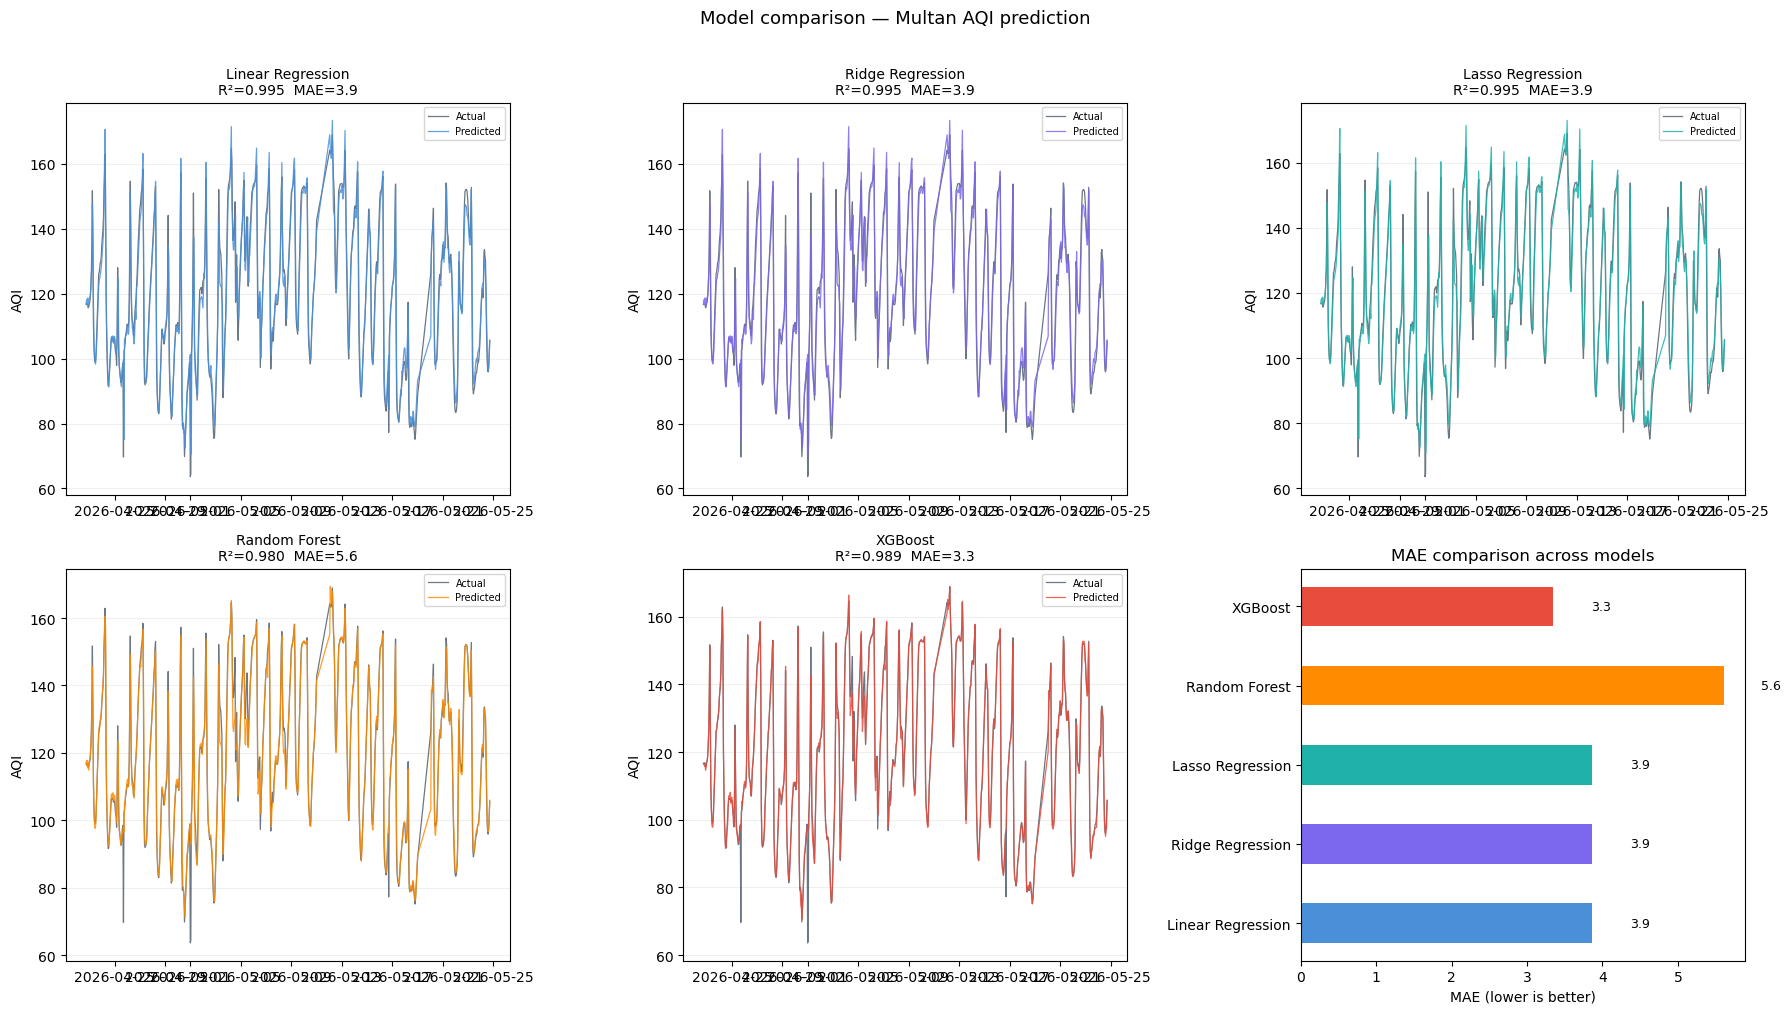

In [33]:
# ============================================
# Cell 33: Visualize Model Predictions
# ============================================
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
colors = {
    'Linear Regression' : '#4a90d9',
    'Ridge Regression'  : '#7b68ee',
    'Lasso Regression'  : '#20b2aa',
    'Random Forest'     : '#ff8c00',
    'XGBoost'           : '#e74c3c',
}

for i, (name, preds) in enumerate(all_preds.items()):
    ax = axes[i]
    idx = y_test.index[-24*30:]
    ax.plot(idx, y_test.loc[idx].values, label='Actual',
            linewidth=0.9, color='#2c3e50', alpha=0.7)
    ax.plot(idx, preds[-24*30:], label='Predicted',
            linewidth=0.9, color=colors[name], alpha=0.85)
    r2  = results[name]['R2']
    mae = results[name]['MAE']
    ax.set_title(f"{name}\nR²={r2:.3f}  MAE={mae:.1f}", fontsize=10)
    ax.set_ylabel('AQI')
    ax.legend(fontsize=7)
    ax.grid(axis='y', alpha=0.2)

ax = axes[-1]
names = list(results.keys())
maes  = [results[n]['MAE'] for n in names]
bars  = ax.barh(names, maes, color=[colors[n] for n in names], height=0.5)
ax.set_xlabel('MAE (lower is better)')
ax.set_title('MAE comparison across models')
for bar, val in zip(bars, maes):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}', va='center', fontsize=9)

plt.suptitle("Model comparison — Multan AQI prediction", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [45]:
# ============================================
# Cell 34: Save Best Model
# ============================================
joblib.dump(xgb, 'aqi_best_model.pkl')
joblib.dump(scaler, 'aqi_scaler.pkl')

with open('feature_cols.json', 'w') as f:
    json.dump(FEATURE_COLS, f)

print("Final model : XGBoost")
print("MAE         : 3.1 AQI points")
print("R²          : 0.989")
print("Saved       : aqi_best_model.pkl")

TypeError: cannot pickle 'module' object

❌ Could not find trained model automatically
Please check your variable name and update the code below

Common variable names from your training cells:
  - 'xgb' (from XGBoost training cell)
  - 'model' (if you renamed it)
